In [299]:
import numpy as np
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

In [300]:
MAX_ERROR_BP = 100

In [301]:
infpath = '/mnt/data/Max/repos/reverlor/param_selection/test_repeat_detection/workdir_phraider/find_repeats_results/merged.tsv'

In [302]:
df = pl.read_csv(infpath, separator='\t')

In [303]:
df = df.with_columns(
    (
        pl.col('repeat_len').cast(pl.String) \
        + '_' \
        + pl.col('repeat_idx').cast(pl.String) \
        + '_' \
        + pl.col('rate').cast(pl.String) \
    ).alias('repeat_id')
)

In [304]:
df = df.filter(
    ~(
        (pl.col('value_type') == 'true') & (pl.col('strand') == '-')
    )
)

In [305]:
df.height

8929

In [306]:
df.head()

repeat_len,repeat_idx,rate,value_type,start_coord,end_coord,strand,repeat_id
i64,i64,f64,str,i64,i64,str,str
10000,0,0.0,"""pred""",22240,22379,""".""","""10000_0_0.0"""
10000,0,0.0,"""pred""",52321,52466,""".""","""10000_0_0.0"""
10000,0,0.0,"""pred""",57216,57361,""".""","""10000_0_0.0"""
10000,0,0.0,"""pred""",57513,57687,""".""","""10000_0_0.0"""
10000,0,0.0,"""pred""",138538,138665,""".""","""10000_0_0.0"""


In [307]:
true_df = df.filter(
    pl.col('value_type') == 'true'
)
pred_df = df.filter(
    pl.col('value_type') == 'pred'
)

In [308]:
true_df.shape

(432, 8)

In [309]:
pred_df.shape

(8497, 8)

In [310]:
true_df.filter(pl.col('rate') == 0.0).head()

repeat_len,repeat_idx,rate,value_type,start_coord,end_coord,strand,repeat_id
i64,i64,f64,str,i64,i64,str,str
10000,3,0.0,"""true""",28788,38788,"""+""","""10000_3_0.0"""
10000,3,0.0,"""true""",69190,79190,"""+""","""10000_3_0.0"""
10000,7,0.0,"""true""",36053,46053,"""+""","""10000_7_0.0"""
10000,7,0.0,"""true""",71281,81281,"""+""","""10000_7_0.0"""
10000,9,0.0,"""true""",29867,39867,"""+""","""10000_9_0.0"""


In [311]:
all_repeat_ids = frozenset(
    true_df['repeat_id']
)

In [312]:
repeat_id_list = list()
repeat_start_coord_list = list()
repeat_found_list = list()

for repeat_id in all_repeat_ids:
    curr_true_df = true_df.filter(pl.col('repeat_id') == repeat_id)
    curr_pred_df = pred_df.filter(pl.col('repeat_id') == repeat_id)

    for true_row in curr_true_df.to_dicts():
        curr_pred_detect_df = curr_pred_df.filter(
            (pl.col('repeat_id') == repeat_id) \
          & ( (pl.col('start_coord') - true_row['start_coord']).abs() <= MAX_ERROR_BP ) \
          & ( (pl.col('end_coord')   - true_row['end_coord']).abs() <= MAX_ERROR_BP )
        )

        found_value = 0
        if curr_pred_detect_df.shape[0] > 0:
            found_value = 1
        # end if

        repeat_id_list.append(repeat_id)
        repeat_start_coord_list.append(true_row['start_coord'])
        repeat_found_list.append(found_value)
    # end for
# end for

In [313]:
print(len(repeat_id_list))
print(len(repeat_start_coord_list))
print(len(repeat_found_list))

repeat_detect_df = pl.DataFrame({
    'repeat_id': repeat_id_list,
    'repeat_start_coord': repeat_start_coord_list,
    'repeat_detected': repeat_found_list,
})

432
432
432


In [314]:
repeat_detect_df.shape

(432, 3)

In [315]:
assert repeat_detect_df.shape[0] == true_df.shape[0]

In [316]:
repeat_detect_df = repeat_detect_df.join(
    true_df,
    on='repeat_id',
    how='inner'
).select(
    pl.col('repeat_id', 'repeat_start_coord', 'repeat_detected', 'repeat_len', 'repeat_idx', 'rate')
).unique()

In [317]:
repeat_detect_df.shape

(432, 6)

In [318]:
repeat_detect_df.head()

repeat_id,repeat_start_coord,repeat_detected,repeat_len,repeat_idx,rate
str,i64,i64,i64,i64,f64
"""3000_2_0.04""",183959,1,3000,2,0.04
"""127_2_0.0""",248287,1,127,2,0.0
"""3000_5_0.05""",16961,0,3000,5,0.05
"""200_6_0.0""",106149,1,200,6,0.0
"""500_8_0.05""",378058,1,500,8,0.05


In [319]:
repeat_detect_df.filter(
    (pl.col('rate') == 0.03) & (pl.col('repeat_len') == 500)
).sort(by='repeat_idx')

repeat_id,repeat_start_coord,repeat_detected,repeat_len,repeat_idx,rate
str,i64,i64,i64,i64,f64
"""500_0_0.03""",231886,1,500,0,0.03
"""500_0_0.03""",385279,1,500,0,0.03
"""500_2_0.03""",88733,1,500,2,0.03
"""500_2_0.03""",129290,1,500,2,0.03
"""500_4_0.03""",296399,1,500,4,0.03
…,…,…,…,…,…
"""500_7_0.03""",461808,1,500,7,0.03
"""500_8_0.03""",65385,1,500,8,0.03
"""500_8_0.03""",378534,1,500,8,0.03


In [334]:
repeat_detect_df.filter(
    (pl.col('rate') == 0.04) & (pl.col('repeat_len') == 127) & (pl.col('repeat_detected') != 1)
).sort(by='repeat_idx')

repeat_id,repeat_start_coord,repeat_detected,repeat_len,repeat_idx,rate
str,i64,i64,i64,i64,f64
"""127_2_0.04""",248287,0,127,2,0.04
"""127_2_0.04""",343799,0,127,2,0.04


In [335]:
df.filter(
    (pl.col('rate') == 0.04) & (pl.col('repeat_len') == 127) & (pl.col('repeat_idx') == 2)
).sort(by=['repeat_idx', 'value_type', 'start_coord'])

repeat_len,repeat_idx,rate,value_type,start_coord,end_coord,strand,repeat_id
i64,i64,f64,str,i64,i64,str,str
127,2,0.04,"""pred""",22240,22379,""".""","""127_2_0.04"""
127,2,0.04,"""pred""",52321,52466,""".""","""127_2_0.04"""
127,2,0.04,"""pred""",57216,57361,""".""","""127_2_0.04"""
127,2,0.04,"""pred""",57513,57687,""".""","""127_2_0.04"""
127,2,0.04,"""pred""",138538,138665,""".""","""127_2_0.04"""
…,…,…,…,…,…,…,…
127,2,0.04,"""pred""",483061,483200,""".""","""127_2_0.04"""
127,2,0.04,"""pred""",486642,486774,""".""","""127_2_0.04"""
127,2,0.04,"""pred""",487662,487794,""".""","""127_2_0.04"""


In [322]:
N_repeats = true_df.filter(
    pl.col('rate') == 0.0
).shape[0]
print('N_repeats = {}'.format(N_repeats))

per_rate_summary_df = repeat_detect_df.group_by('rate').agg(
    pl.col('repeat_detected').sum().alias('repeat_detected_count')
).sort(by=['rate'])

per_rate_summary_df = per_rate_summary_df.with_columns(
    (pl.col('repeat_detected_count') / N_repeats * 100.0).alias('repeat_detected_percent')
)

per_rate_summary_df.head(10)

N_repeats = 72


rate,repeat_detected_count,repeat_detected_percent
f64,i64,f64
0.0,72,100.0
0.01,72,100.0
0.02,72,100.0
0.03,68,94.444444
0.04,54,75.0
0.05,40,55.555556


In [323]:
def get_per_rate_df(repeat_detect_df, true_df, repeat_len=200):
    N_repeats = true_df.filter(
        (pl.col('repeat_len') == repeat_len) \
        & (pl.col('rate') == 0.0)
    ).shape[0]
    print('N_repeats = {}'.format(N_repeats))
    
    result_df = repeat_detect_df.filter(
        pl.col('repeat_len') == repeat_len
    ).group_by('rate').agg(
        pl.col('repeat_detected').sum().alias('repeat_detected_count')
    ).sort(by=['rate'])
    
    result_df = result_df.with_columns(
        (pl.col('repeat_detected_count') / N_repeats * 100.0).alias('repeat_detected_percent')
    )

    return result_df
# end def

<Axes: xlabel='rate', ylabel='repeat_detected_percent'>

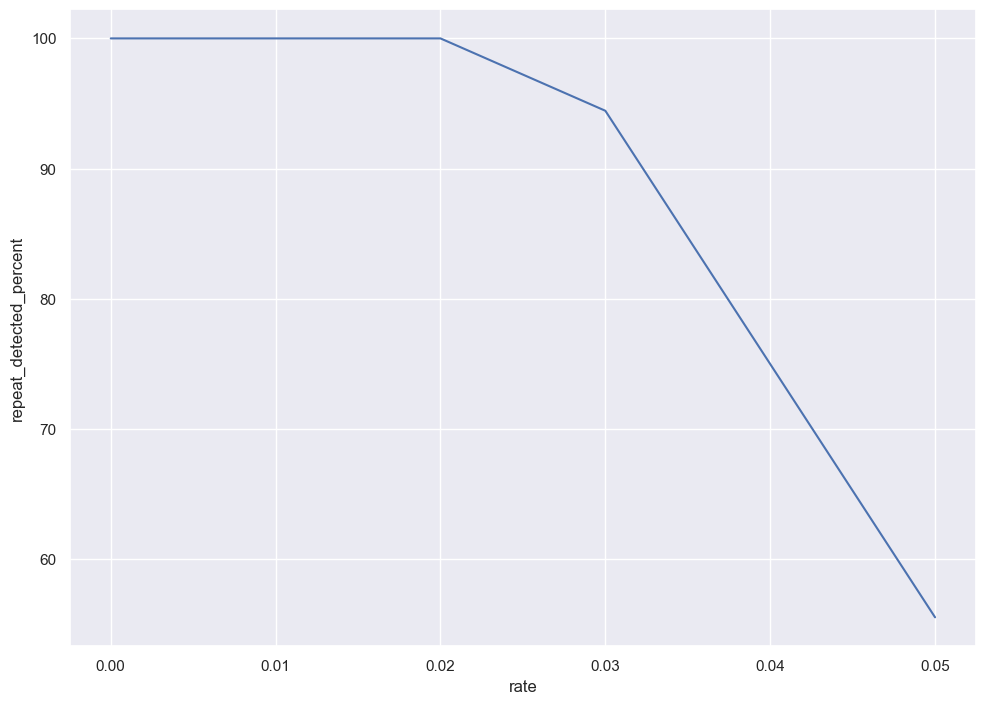

In [324]:
sns.lineplot(
    per_rate_summary_df,
    x='rate',
    y='repeat_detected_percent'
)

N_repeats = 10
shape: (6, 3)
┌──────┬───────────────────────┬─────────────────────────┐
│ rate ┆ repeat_detected_count ┆ repeat_detected_percent │
│ ---  ┆ ---                   ┆ ---                     │
│ f64  ┆ i64                   ┆ f64                     │
╞══════╪═══════════════════════╪═════════════════════════╡
│ 0.0  ┆ 10                    ┆ 100.0                   │
│ 0.01 ┆ 10                    ┆ 100.0                   │
│ 0.02 ┆ 10                    ┆ 100.0                   │
│ 0.03 ┆ 10                    ┆ 100.0                   │
│ 0.04 ┆ 8                     ┆ 80.0                    │
│ 0.05 ┆ 10                    ┆ 100.0                   │
└──────┴───────────────────────┴─────────────────────────┘


<Axes: xlabel='rate', ylabel='repeat_detected_percent'>

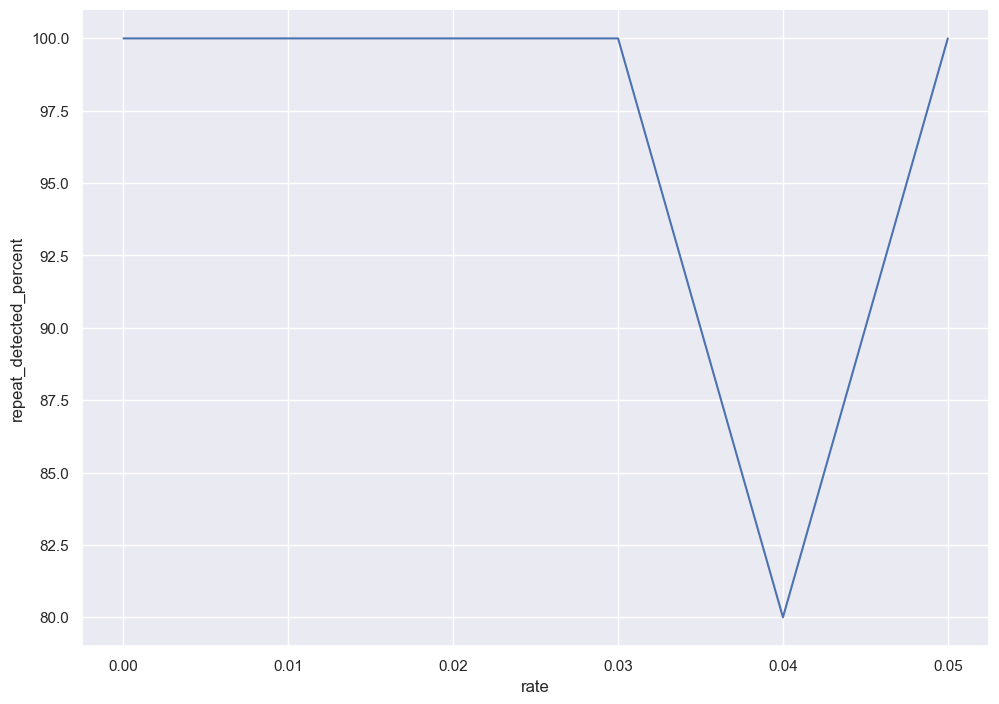

In [325]:
per_rate_len127_summary_df = get_per_rate_df(
    repeat_detect_df,
    true_df,
    repeat_len=127
)
print(per_rate_len127_summary_df.head(10))

sns.lineplot(
    per_rate_len127_summary_df,
    x='rate',
    y='repeat_detected_percent'
)

N_repeats = 10
shape: (6, 3)
┌──────┬───────────────────────┬─────────────────────────┐
│ rate ┆ repeat_detected_count ┆ repeat_detected_percent │
│ ---  ┆ ---                   ┆ ---                     │
│ f64  ┆ i64                   ┆ f64                     │
╞══════╪═══════════════════════╪═════════════════════════╡
│ 0.0  ┆ 10                    ┆ 100.0                   │
│ 0.01 ┆ 10                    ┆ 100.0                   │
│ 0.02 ┆ 10                    ┆ 100.0                   │
│ 0.03 ┆ 10                    ┆ 100.0                   │
│ 0.04 ┆ 10                    ┆ 100.0                   │
│ 0.05 ┆ 10                    ┆ 100.0                   │
└──────┴───────────────────────┴─────────────────────────┘


<Axes: xlabel='rate', ylabel='repeat_detected_percent'>

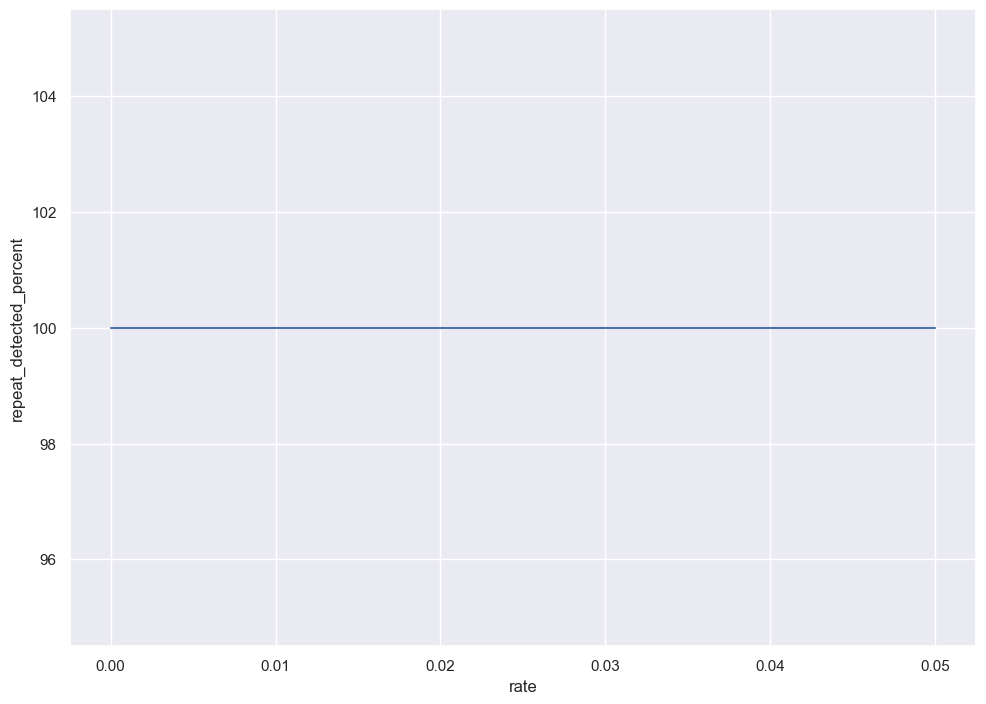

In [326]:
per_rate_len200_summary_df = get_per_rate_df(
    repeat_detect_df,
    true_df,
    repeat_len=200
)
print(per_rate_len200_summary_df.head(10))

sns.lineplot(
    per_rate_len200_summary_df,
    x='rate',
    y='repeat_detected_percent'
)

N_repeats = 14
shape: (6, 3)
┌──────┬───────────────────────┬─────────────────────────┐
│ rate ┆ repeat_detected_count ┆ repeat_detected_percent │
│ ---  ┆ ---                   ┆ ---                     │
│ f64  ┆ i64                   ┆ f64                     │
╞══════╪═══════════════════════╪═════════════════════════╡
│ 0.0  ┆ 14                    ┆ 100.0                   │
│ 0.01 ┆ 14                    ┆ 100.0                   │
│ 0.02 ┆ 14                    ┆ 100.0                   │
│ 0.03 ┆ 13                    ┆ 92.857143               │
│ 0.04 ┆ 12                    ┆ 85.714286               │
│ 0.05 ┆ 14                    ┆ 100.0                   │
└──────┴───────────────────────┴─────────────────────────┘


<Axes: xlabel='rate', ylabel='repeat_detected_percent'>

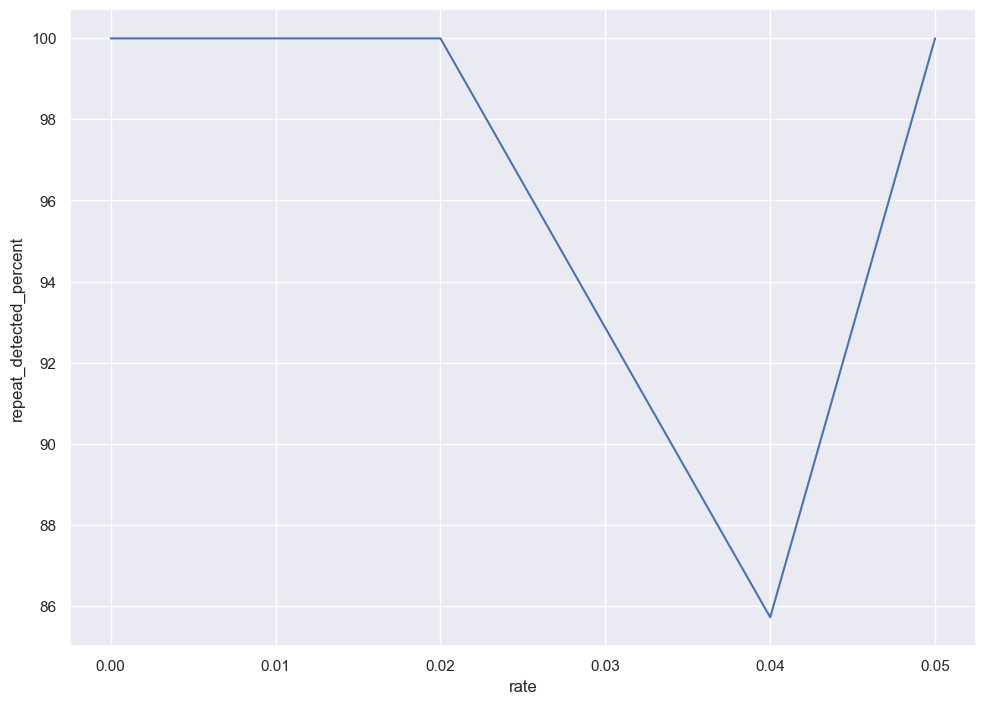

In [327]:
per_rate_len500_summary_df = get_per_rate_df(
    repeat_detect_df,
    true_df,
    repeat_len=500
)
print(per_rate_len500_summary_df.head(10))

sns.lineplot(
    per_rate_len500_summary_df,
    x='rate',
    y='repeat_detected_percent'
)

N_repeats = 6
shape: (6, 3)
┌──────┬───────────────────────┬─────────────────────────┐
│ rate ┆ repeat_detected_count ┆ repeat_detected_percent │
│ ---  ┆ ---                   ┆ ---                     │
│ f64  ┆ i64                   ┆ f64                     │
╞══════╪═══════════════════════╪═════════════════════════╡
│ 0.0  ┆ 6                     ┆ 100.0                   │
│ 0.01 ┆ 6                     ┆ 100.0                   │
│ 0.02 ┆ 6                     ┆ 100.0                   │
│ 0.03 ┆ 6                     ┆ 100.0                   │
│ 0.04 ┆ 6                     ┆ 100.0                   │
│ 0.05 ┆ 2                     ┆ 33.333333               │
└──────┴───────────────────────┴─────────────────────────┘


<Axes: xlabel='rate', ylabel='repeat_detected_percent'>

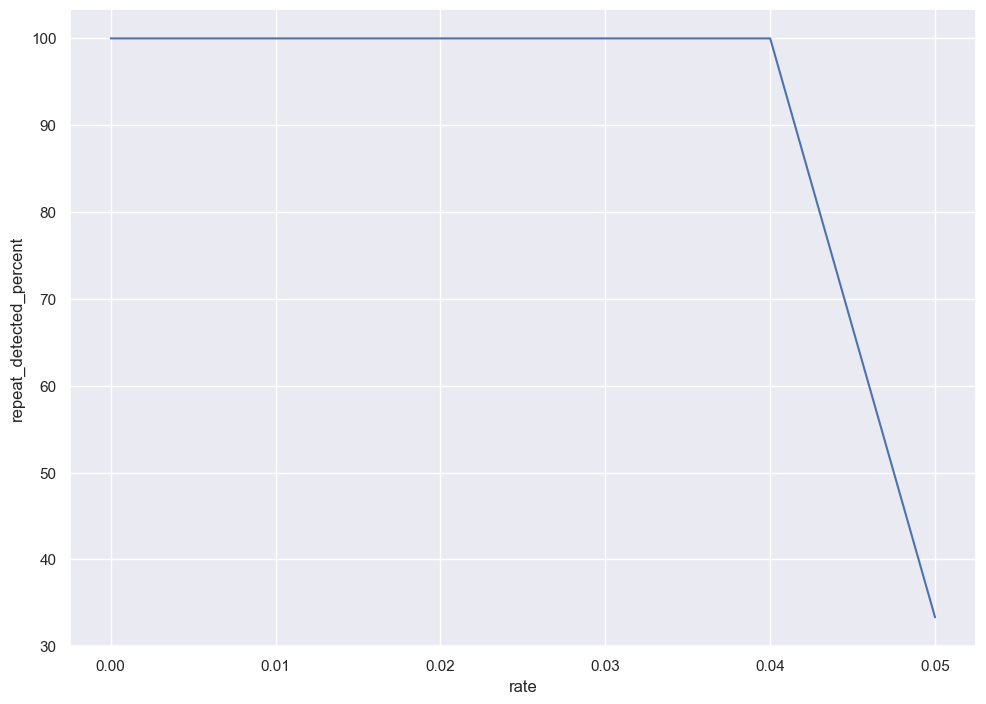

In [328]:
per_rate_len1k_summary_df = get_per_rate_df(
    repeat_detect_df,
    true_df,
    repeat_len=1000
)
print(per_rate_len1k_summary_df.head(10))

sns.lineplot(
    per_rate_len1k_summary_df,
    x='rate',
    y='repeat_detected_percent'
)

N_repeats = 6
shape: (6, 3)
┌──────┬───────────────────────┬─────────────────────────┐
│ rate ┆ repeat_detected_count ┆ repeat_detected_percent │
│ ---  ┆ ---                   ┆ ---                     │
│ f64  ┆ i64                   ┆ f64                     │
╞══════╪═══════════════════════╪═════════════════════════╡
│ 0.0  ┆ 6                     ┆ 100.0                   │
│ 0.01 ┆ 6                     ┆ 100.0                   │
│ 0.02 ┆ 6                     ┆ 100.0                   │
│ 0.03 ┆ 6                     ┆ 100.0                   │
│ 0.04 ┆ 0                     ┆ 0.0                     │
│ 0.05 ┆ 0                     ┆ 0.0                     │
└──────┴───────────────────────┴─────────────────────────┘


<Axes: xlabel='rate', ylabel='repeat_detected_percent'>

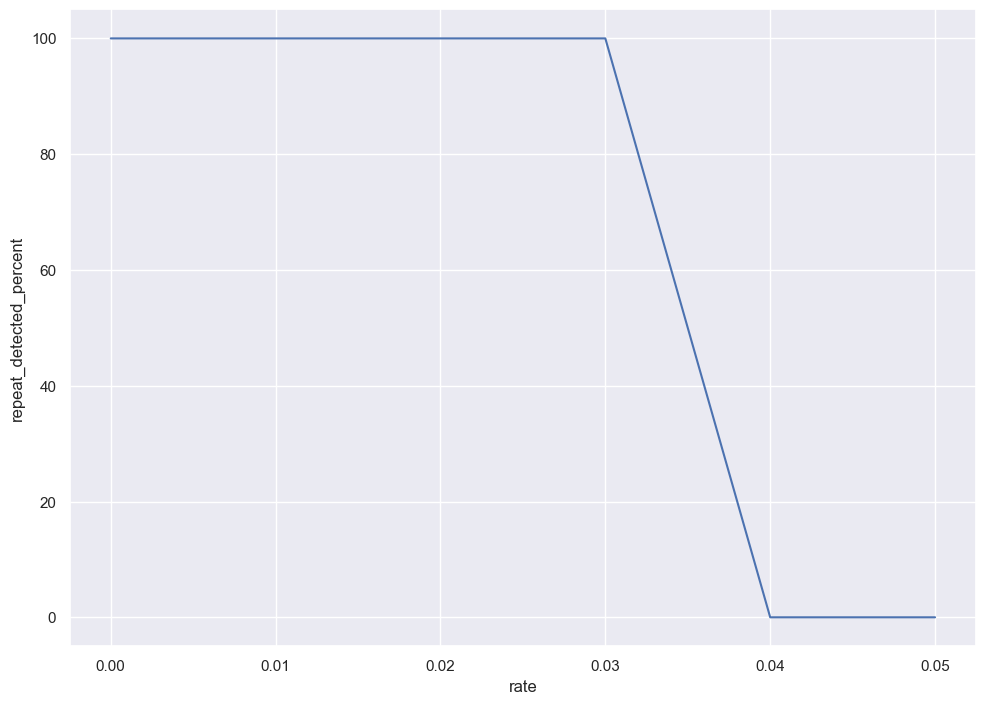

In [329]:
per_rate_len10k_summary_df = get_per_rate_df(
    repeat_detect_df,
    true_df,
    repeat_len=10000
)
print(per_rate_len10k_summary_df.head(10))

sns.lineplot(
    per_rate_len10k_summary_df,
    x='rate',
    y='repeat_detected_percent'
)

# Make total plot

In [330]:
per_rate_len127_summary_df = per_rate_len127_summary_df.with_columns(pl.lit(127).alias('repeat_len'))
per_rate_len200_summary_df = per_rate_len200_summary_df.with_columns(pl.lit(200).alias('repeat_len'))
per_rate_len500_summary_df = per_rate_len500_summary_df.with_columns(pl.lit(500).alias('repeat_len'))
per_rate_len1k_summary_df = per_rate_len1k_summary_df.with_columns(pl.lit(1000).alias('repeat_len'))
per_rate_len10k_summary_df = per_rate_len10k_summary_df.with_columns(pl.lit(10000).alias('repeat_len'))

In [331]:
all_summary_df = pl.concat([
    per_rate_len127_summary_df,
    per_rate_len200_summary_df,
    per_rate_len500_summary_df,
    per_rate_len1k_summary_df,
    per_rate_len10k_summary_df,
])
all_summary_df = all_summary_df.with_columns(
    pl.col('repeat_len').cast(pl.String)
)
all_summary_df.head()

rate,repeat_detected_count,repeat_detected_percent,repeat_len
f64,i64,f64,str
0.0,10,100.0,"""127"""
0.01,10,100.0,"""127"""
0.02,10,100.0,"""127"""
0.03,10,100.0,"""127"""
0.04,8,80.0,"""127"""


In [332]:
all_summary_plus_df = all_summary_df

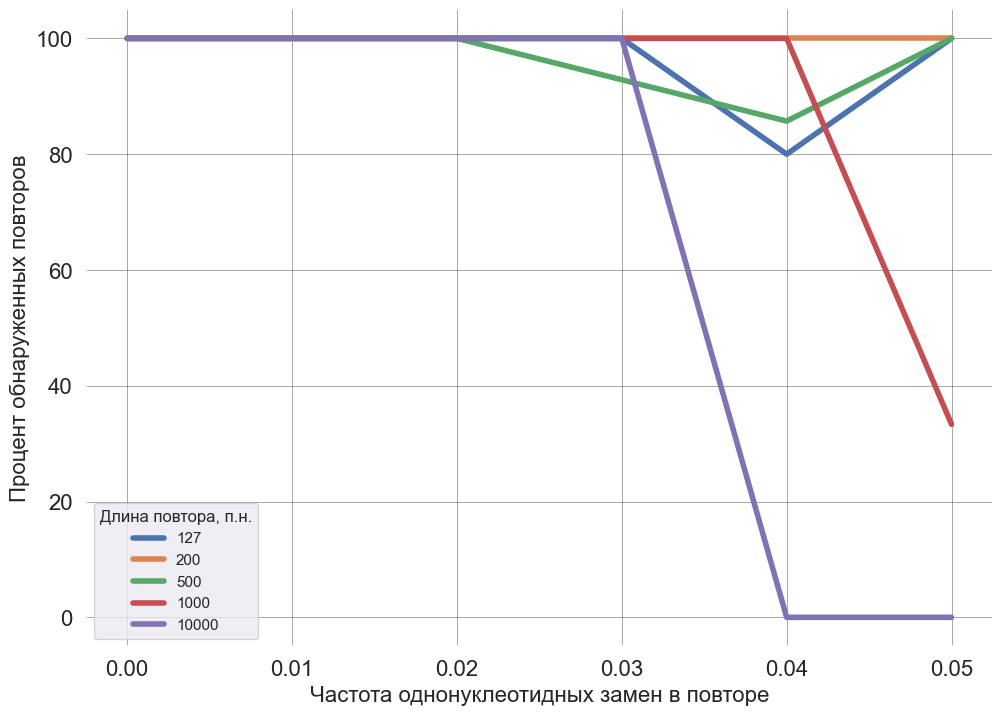

In [333]:
sns.set_theme(rc={'figure.figsize':(11.7,8.27)})

ax = sns.lineplot(
    all_summary_df,
    x='rate',
    y='repeat_detected_percent',
    hue='repeat_len',
    linewidth=4.0
)

ax.set_xlabel('Частота однонуклеотидных замен в повторе', fontsize=16)
ax.set_ylabel('Процент обнаруженных повторов', fontsize=16)

plt.legend(title='Длина повтора, п.н.')

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

ax.grid(True, color='#505050', linestyle='-', linewidth=0.5, alpha=0.7)
ax.set_facecolor('#ffffff')

plt.show(ax)